# Feature Relationships

## Introduction

Feature relationships help us understand how different features in a dataset are related to each other and how they may affect the target variable.

In Machine Learning, understanding feature relationships is important because highly related or unnecessary features can affect model performance.

The main topics covered in this notebook are:

- Correlation Matrix
- Multicollinearity
- Variance Inflation Factor (VIF)
- Feature Importance
- Feature Selection Basics

## 1. Correlation Matrix
### Definition

A Correlation Matrix is a table that shows the correlation between multiple numerical variables.

The correlation value ranges from:

-1 to +1

+1 → Perfect positive correlation
0 → No linear correlation
-1 → Perfect negative correlation

A correlation matrix helps us quickly understand relationships between features.

### Formula

Pearson correlation is commonly calculated as:

r = Cov(X,Y) / (σX × σY)

Where:

- Cov(X,Y) = covariance between X and Y
- σX = standard deviation of X
- σY = standard deviation of Y
### Simple Example

Suppose we have:

| Study Hours | Marks |
|-------------|-------|
| 1           | 40    |
| 2           | 50    |
| 3           | 60    |
| 4           | 70    |
| 5           | 80    |

As study hours increase, marks also increase.

Therefore, the correlation is close to +1.

### Python Implementation

In [2]:
import pandas as pd

data = pd.DataFrame({
    "Study_Hours": [1, 2, 3, 4, 5],
    "Marks": [40, 50, 60, 70, 80],
    "Attendance": [60, 65, 70, 80, 90],
    "Assignments": [2, 3, 4, 4, 5]
})

correlation_matrix = data.corr()

print(correlation_matrix)

             Study_Hours     Marks  Attendance  Assignments
Study_Hours     1.000000  1.000000    0.984798     0.970725
Marks           1.000000  1.000000    0.984798     0.970725
Attendance      0.984798  0.984798    1.000000     0.928655
Assignments     0.970725  0.970725    0.928655     1.000000


### Visualization

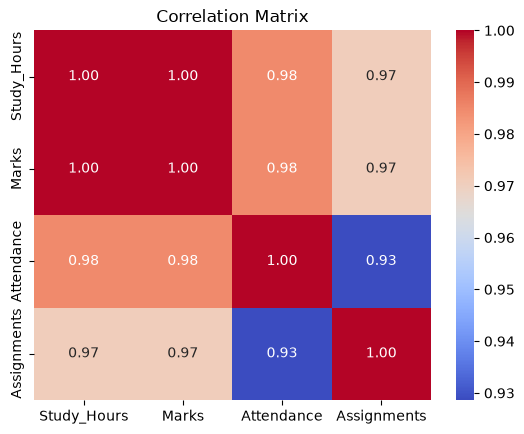

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.DataFrame({
    "Study_Hours": [1, 2, 3, 4, 5],
    "Marks": [40, 50, 60, 70, 80],
    "Attendance": [60, 65, 70, 80, 90],
    "Assignments": [2, 3, 4, 4, 5]
})

correlation_matrix = data.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### Business Example

A company can use a correlation matrix to understand relationships between:

- Advertising spending
- Sales
- Customer visits
- Revenue

For example, advertising spending may have a positive correlation with sales.

### AI/ML Example

Before training a Machine Learning model, a correlation matrix can help identify:

- Highly related features
- Features related to the target
- Potential multicollinearity
### Interpretation

A correlation value close to:

- +1 → Strong positive relationship
- -1 → Strong negative relationship
- 0 → Weak or no linear relationship

Correlation shows association, not causation.

## 2. Multicollinearity
### Definition

Multicollinearity occurs when two or more independent features in a dataset are highly correlated with each other.

In simple words:

Multicollinearity = Features contain similar information.

### Simple Example

Suppose a dataset contains:

- Age in years
- Age in months

These two features contain almost the same information.

Therefore, they can create multicollinearity.

### Numerical Example

Suppose:

Age in years = 25

Age in months = 300

These features are directly related:

Age in months = Age in years × 12

Therefore, they have very high correlation.

### Python Implementation

In [4]:
import pandas as pd

data = pd.DataFrame({
    "Age_Years": [20, 21, 22, 23, 24],
    "Age_Months": [240, 252, 264, 276, 288],
    "Salary": [25000, 27000, 29000, 31000, 33000]
})

correlation_matrix = data.corr()

print(correlation_matrix)

            Age_Years  Age_Months  Salary
Age_Years         1.0         1.0     1.0
Age_Months        1.0         1.0     1.0
Salary            1.0         1.0     1.0


### Business Example

A company dataset may contain:

- Annual salary
- Monthly salary

These features contain almost the same information and may create multicollinearity.

### AI/ML Example

In Linear Regression, multicollinearity can make coefficient estimates unstable.

For example:

- House size in square feet
- Number of rooms
- Number of bedrooms

These features may be strongly related.

### Interpretation

High correlation between independent features can indicate possible multicollinearity.

A common warning sign is:

Correlation > 0.8 or < -0.8

However, correlation alone is not enough to fully diagnose multicollinearity.

## 3. Variance Inflation Factor (VIF)
### Definition

Variance Inflation Factor (VIF) is a statistical measure used to detect multicollinearity among independent features.

VIF tells us how much the variance of an estimated regression coefficient is increased because of relationships between features.

### Formula

VIF = 1 / (1 - R²)

Where:

R² = R-squared value obtained by predicting one feature using the other features.

### VIF Interpretation

A common guideline is:

| VIF | Interpretation |
|-----|----------------|
| 1 | No multicollinearity |
| 1–5 | Usually acceptable |
| 5–10 | High multicollinearity |
| >10 | Very high multicollinearity |

These are practical guidelines rather than strict universal rules.

### Simple Example
Suppose we calculate VIF:

| Feature    | VIF |
|------------|-----|
| Age        | 1.5 |
| Salary     | 2.1 |
| Experience | 8.5 |

Experience has a high VIF, indicating that it may be strongly related to other features.

### Python Implementation

In [5]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

data = pd.DataFrame({
    "Age": [22, 25, 28, 30, 32, 35, 38, 40],
    "Experience": [1, 3, 5, 7, 9, 12, 15, 17],
    "Salary": [25000, 30000, 35000, 42000, 48000, 55000, 65000, 70000]
})

X = data

vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

      Feature          VIF
0         Age  1264.946560
1  Experience   420.127549
2      Salary  3013.561741


### Business Example

A company may have:

- Monthly salary
- Annual salary
- Total compensation

These features can be highly related.

VIF can help identify redundant variables.

### AI/ML Example

VIF is particularly useful before building regression models.

If a feature has a very high VIF, we may investigate whether it should be removed or transformed.

### Interpretation

A high VIF indicates that a feature can be strongly explained by other features.

A VIF close to 1 indicates little multicollinearity.

## 4. Feature Importance
### Definition

Feature Importance tells us how useful each feature is for making predictions in a Machine Learning model.

It helps us understand which features contribute more to the model's predictions.

Different models calculate feature importance differently.

Examples:

- Decision Trees
- Random Forest
- Gradient Boosting
- XGBoost
### Simple Example

Suppose we predict house prices using:

- Area
- Number of bedrooms
- Location score
- Age of house

The model may give:

| Feature        | Importance |
|----------------|------------|
| Area           | 0.45       |
| Location Score | 0.30       |
| Bedrooms       | 0.15       |
| House Age      | 0.10       |

### Python Implementation

In [6]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

data = pd.DataFrame({
    "Area": [1000, 1200, 1500, 1800, 2000, 2200, 2500, 2800],
    "Bedrooms": [2, 2, 3, 3, 4, 4, 4, 5],
    "Age": [10, 8, 7, 6, 5, 4, 3, 2],
    "Price": [50, 60, 75, 90, 110, 125, 145, 170]
})

X = data[["Area", "Bedrooms", "Age"]]
y = data["Price"]

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

print(feature_importance.sort_values(
    by="Importance",
    ascending=False
))

    Feature  Importance
0      Area    0.392598
2       Age    0.326153
1  Bedrooms    0.281249


### Visualization

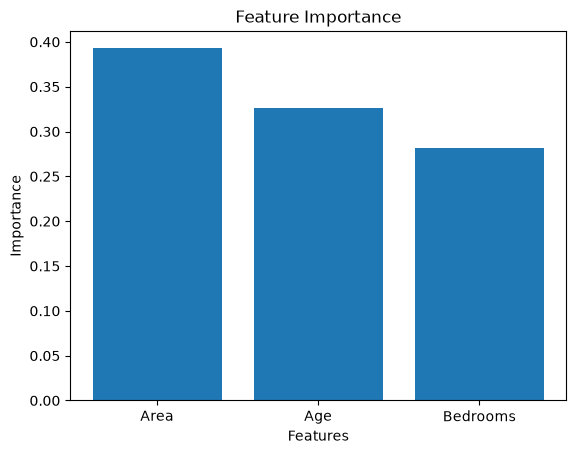

In [7]:
import matplotlib.pyplot as plt

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

### Business Example

An e-commerce company predicts customer spending.

Feature importance can show whether:

- Previous purchases
- Website visits
- Discount usage
- Customer age

are more useful for prediction.

### AI/ML Example

Feature importance helps identify which input variables contribute most to a Machine Learning model's predictions.

### Interpretation

A higher importance score generally means the feature contributed more to the model's predictions under that model's importance definition.

Feature importance should not automatically be interpreted as causation.

## 5. Feature Selection Basics
### Definition

Feature Selection is the process of selecting the most useful features from a dataset for Machine Learning.

The goal is to remove:

- Irrelevant features
- Redundant features
- Noisy features
- Duplicate information
### Simple Example

Suppose we have 10 features:

- Age
- Salary
- Experience
- City
- Random_ID
- Name
- Department
- Education
- Purchase_History
- Website_Visits

Some features may not help the prediction.

Feature selection helps us keep the useful features.

### Main Feature Selection Methods
#### 1. Filter Methods

These methods select features using statistical measures.

Examples:

- Correlation
- Chi-Square
- ANOVA
- Mutual Information
#### 2. Wrapper Methods

These methods test different combinations of features using a Machine Learning model.

Examples:

- Recursive Feature Elimination (RFE)
- Sequential Feature Selection
#### 3. Embedded Methods

Feature selection happens during model training.

Examples:

- Lasso Regression
- Decision Trees
- Random Forest
### Python Implementation – Correlation Based Selection

In [8]:
import pandas as pd

data = pd.DataFrame({
    "Study_Hours": [1, 2, 3, 4, 5, 6],
    "Attendance": [60, 65, 70, 75, 80, 85],
    "Random_Feature": [12, 5, 20, 8, 30, 2],
    "Marks": [40, 48, 55, 65, 75, 85]
})

correlation = data.corr()["Marks"].abs()

print(correlation)

selected_features = correlation[
    correlation > 0.5
].index

print("Selected Features:")
print(selected_features)

Study_Hours       0.997618
Attendance        0.997618
Random_Feature    0.042092
Marks             1.000000
Name: Marks, dtype: float64
Selected Features:
Index(['Study_Hours', 'Attendance', 'Marks'], dtype='str')


### Python Implementation – RFE

In [9]:
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

data = pd.DataFrame({
    "Study_Hours": [1, 2, 3, 4, 5, 6, 7, 8],
    "Attendance": [60, 65, 70, 75, 80, 85, 90, 95],
    "Assignments": [2, 3, 3, 4, 4, 5, 5, 6],
    "Random_Feature": [10, 30, 5, 25, 8, 40, 2, 15],
    "Marks": [40, 48, 55, 62, 70, 78, 85, 92]
})

X = data.drop("Marks", axis=1)
y = data["Marks"]

model = LinearRegression()

selector = RFE(
    estimator=model,
    n_features_to_select=2
)

selector.fit(X, y)

selected_features = X.columns[selector.support_]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['Study_Hours', 'Attendance'], dtype='str')


In [ ]:
### Business Example

An online shopping company may have hundreds of customer-related features.

Feature selection can reduce the dataset to useful features such as:

- Purchase history
- Website visits
- Average order value
- Customer activity
###AI/ML Example

Feature selection can help reduce model complexity and improve training efficiency.

For example, instead of using 100 features, we may select the 20 most useful features.

Interpretation

Good feature selection can:

Reduce training time.
Reduce model complexity.
Remove noise.
Improve generalization.
Make models easier to interpret.
Advantages
Reduces dimensionality.
Can improve model performance.
Reduces training time.
Helps reduce overfitting.
Improves interpretability.